# Retail Price Optimization Model

### Objective

This project develops a robust price optimization model using the given dataset containing monthly pricing data. The target variable is **lag_price** (next-period optimal price). Models evaluated include Ridge Regression, Random Forest, XGBoost, LightGBM, Gradient Boosting, and SVR. Optuna is used for hyperparameter tuning. SHAP values and Permutation Importance provide model explainability. A Streamlit dashboard enables interactive price prediction.

### [1. Data Preparation](#)
- 1.1 Importing Libraries
- 1.2 Load and Clean Dataset
- 1.3 Handle Missing Values & Aggregation

### [2. Exploratory Data Analysis (EDA)](#)
- 2.1 Price Trends Over Time
- 2.2 Sales Volume Distribution
- 2.3 Competitor Price Analysis
- 2.4 Correlation Heatmap
- 2.5 Seasonality & Decomposition

### [3. Feature Engineering](#)
- 3.1 Lag & Rolling Features (Target: lag_price)
- 3.2 Competitor Price Difference
- 3.3 Temporal Features (Month, Week, Quarter)
- 3.4 Product Attribute Features

### [4. Model Selection & Training](#)
- 4.1 Train-Test Split & Preprocessing
- 4.2 Ridge Regression (Baseline)
- 4.3 Random Forest Regressor
- 4.4 XGBoost Regressor with Lag Features
- 4.5 LightGBM Regressor
- 4.6 Gradient Boosting Regressor
- 4.7 Support Vector Regressor (SVR)

### [5. Model Optimization & Explainability](#)
- 5.1 Hyperparameter Tuning with Optuna (XGBoost & LightGBM)
- 5.2 SHAP Explainability for Random Forest
- 5.3 Permutation Importance 

### [6. Model Evaluation & Visualization](#)
- 6.1 Model Evaluation (R², MAE, RMSE)
- 6.2 Actual vs Predicted Price Visualization
- 6.3 Residual Analysis

### [7. Streamlit Deployment UI (Optional)](#)

### [8. Conclusion](#)

# 1. Data Preparation

### 1.1 Importing Libraries

In [3]:
pip install optuna

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import shap
import warnings
import optuna
from optuna.samplers import TPESampler

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
import lightgbm as lgb

from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Global plot style ──
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.edgecolor": "#555",
    "axes.labelcolor": "#333",
    "xtick.color": "#333",
    "ytick.color": "#333",
    "figure.facecolor": "#fff",
})

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


### 1.2 Load and Clean Dataset

In [5]:
# ── Load real retail dataset ─
df = pd.read_csv("retail_price.csv")

# Parse month_year as datetime (format: DD-MM-YYYY)
df["Date"] = pd.to_datetime(df["month_year"], format="%d-%m-%Y")
df.drop(columns=["month_year"], inplace=True)

# Rename columns for clarity
df.rename(columns={
    "product_id":                  "Product",
    "product_category_name":       "Category",
    "qty":                         "Sales_Volume",
    "unit_price":                  "Price",
    "product_score":               "Rating",
    "product_weight_g":            "Weight_g",
    "product_name_lenght":         "Name_Length",
    "product_description_lenght":  "Desc_Length",
    "product_photos_qty":          "Photos_Qty",
    "lag_price":                   "Lag_Price",
    "comp_1":                      "Competitor_Price_1",
    "comp_2":                      "Competitor_Price_2",
    "comp_3":                      "Competitor_Price_3",
    "ps1": "Comp1_Score", "ps2": "Comp2_Score", "ps3": "Comp3_Score",
    "fp1": "Comp1_Freight", "fp2": "Comp2_Freight", "fp3": "Comp3_Freight",
    "s":   "Seasonality_Index",
}, inplace=True)

df.set_index("Date", inplace=True)
df.sort_index(inplace=True)

print(f"Dataset shape: {df.shape}")
print(df.dtypes)
df.head()

Dataset shape: (676, 29)
Product                object
Category               object
Sales_Volume            int64
total_price           float64
freight_price         float64
Price                 float64
Name_Length             int64
Desc_Length             int64
Photos_Qty              int64
Weight_g                int64
Rating                float64
customers               int64
weekday                 int64
weekend                 int64
holiday                 int64
month                   int64
year                    int64
Seasonality_Index     float64
volume                  int64
Competitor_Price_1    float64
Comp1_Score           float64
Comp1_Freight         float64
Competitor_Price_2    float64
Comp2_Score           float64
Comp2_Freight         float64
Competitor_Price_3    float64
Comp3_Score           float64
Comp3_Freight         float64
Lag_Price             float64
dtype: object


,Product,Category,Sales_Volume,total_price,freight_price,Price,Name_Length,Desc_Length,Photos_Qty,Weight_g,...,Competitor_Price_1,Comp1_Score,Comp1_Freight,Competitor_Price_2,Comp2_Score,Comp2_Freight,Competitor_Price_3,Comp3_Score,Comp3_Freight,Lag_Price
Date,,,,,,,,,,,,,,,,,,,,,
2017-01-01,health7,health_beauty,1,64.99,11.060000,64.99,59,492,2,200,...,64.99,3.9,11.060000,64.99,3.9,11.060000,64.99,3.9,11.060,64.94
2017-01-01,health5,health_beauty,8,2799.20,22.901250,349.90,51,625,1,900,...,349.90,4.3,22.901250,349.90,4.3,22.901250,64.99,3.9,11.060,349.85
2017-02-01,bed2,bed_bath_table,2,179.80,13.020000,89.90,54,245,1,1383,...,89.90,3.9,13.020000,89.90,3.9,13.020000,89.90,3.9,13.020,89.85
2017-02-01,garden8,garden_tools,1,179.99,33.540000,179.99,33,2188,2,7650,...,179.99,4.2,33.540000,179.99,4.2,33.540000,179.99,4.2,33.540,179.94
2017-02-01,health9,health_beauty,11,219.89,11.750909,19.99,48,575,1,100,...,19.99,4.3,11.750909,19.99,4.3,11.750909,64.99,3.9,15.348,19.94


### 1.3 Handle Missing Values & Aggregation

In [6]:
# ── Fill missing values ──
for col in ["Price", "Sales_Volume", "Competitor_Price_1", "Competitor_Price_2", "Competitor_Price_3"]:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

# ── Average competitor price ─
df["Competitor_Price"] = df[["Competitor_Price_1", "Competitor_Price_2", "Competitor_Price_3"]].mean(axis=1).round(2)

# ── Aggregate monthly for overview plots ─
daily = df.groupby("Date").agg(
    Avg_Price=("Price", "mean"),
    Avg_Competitor_Price=("Competitor_Price", "mean"),
    Total_Sales=("Sales_Volume", "sum"),
).round(2)

print(f"\nMonthly aggregated shape: {daily.shape}")
daily.head()

Missing values after cleaning:
Product               0
Category              0
Sales_Volume          0
total_price           0
freight_price         0
Price                 0
Name_Length           0
Desc_Length           0
Photos_Qty            0
Weight_g              0
Rating                0
customers             0
weekday               0
weekend               0
holiday               0
month                 0
year                  0
Seasonality_Index     0
volume                0
Competitor_Price_1    0
Comp1_Score           0
Comp1_Freight         0
Competitor_Price_2    0
Comp2_Score           0
Comp2_Freight         0
Competitor_Price_3    0
Comp3_Score           0
Comp3_Freight         0
Lag_Price             0
dtype: int64

Monthly aggregated shape: (20, 3)


,Avg_Price,Avg_Competitor_Price,Total_Sales
Date,,,
2017-01-01,207.44,159.96,9
2017-02-01,127.83,105.06,35
2017-03-01,122.59,104.34,101
2017-04-01,119.29,106.29,121
2017-05-01,104.79,86.11,222


# 2. Exploratory Data Analysis (EDA)

### 2.1 Price Trends Over Time

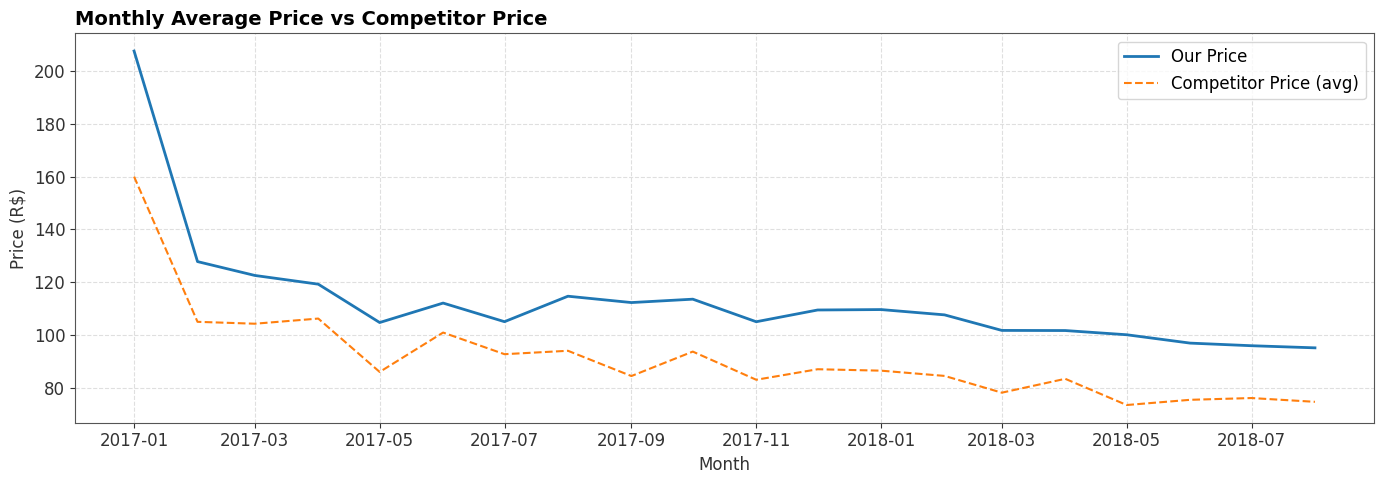

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily.index, daily["Avg_Price"], color="#1f77b4", linewidth=2, label="Our Price")
ax.plot(daily.index, daily["Avg_Competitor_Price"], color="#ff7f0e",
        linewidth=1.5, linestyle="--", label="Competitor Price (avg)")
ax.set_title("Monthly Average Price vs Competitor Price", loc="left")
ax.set_xlabel("Month")
ax.set_ylabel("Price (R$)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 2.2 Sales Volume Distribution

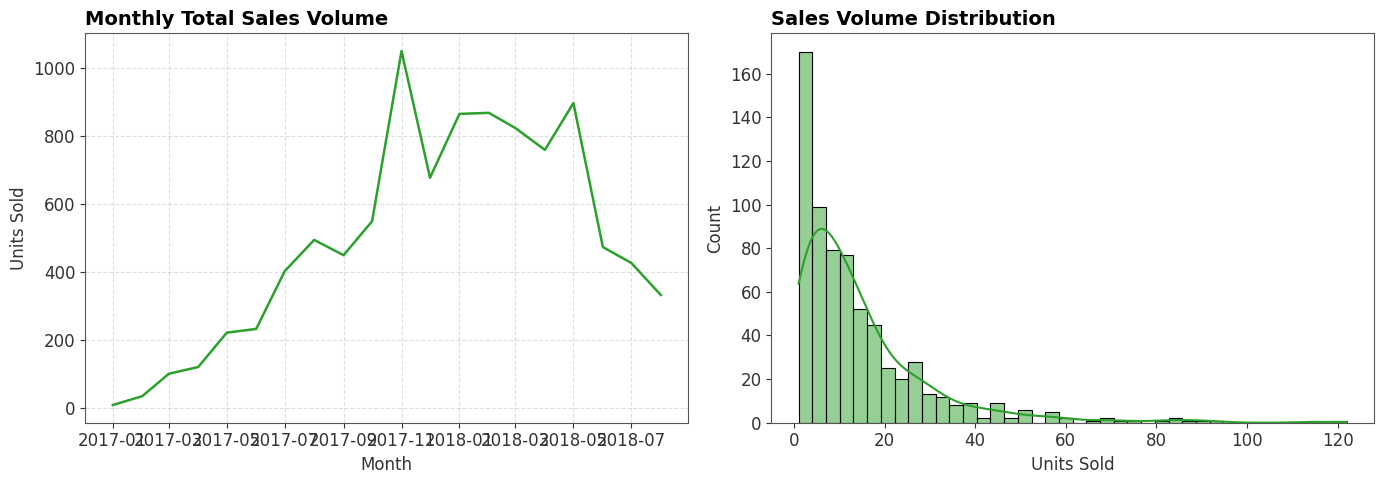

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(daily.index, daily["Total_Sales"], color="#2ca02c", linewidth=1.8)
axes[0].set_title("Monthly Total Sales Volume", loc="left")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Units Sold")
axes[0].grid(True, linestyle="--", alpha=0.4)

sns.histplot(df["Sales_Volume"], bins=40, kde=True, color="#2ca02c", ax=axes[1])
axes[1].set_title("Sales Volume Distribution", loc="left")
axes[1].set_xlabel("Units Sold")

plt.tight_layout()
plt.show()

### 2.3 Competitor Price Analysis

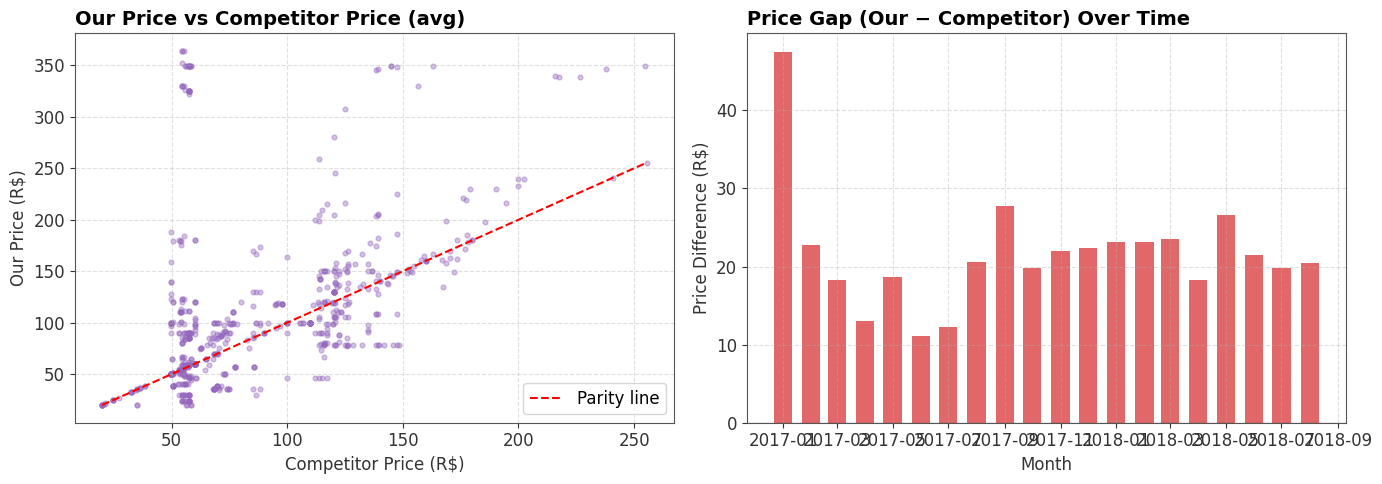

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price gap scatter
axes[0].scatter(df["Competitor_Price"], df["Price"],
                alpha=0.4, color="#9467bd", s=12)
axes[0].plot(
    [df["Competitor_Price"].min(), df["Competitor_Price"].max()],
    [df["Competitor_Price"].min(), df["Competitor_Price"].max()],
    "r--", linewidth=1.5, label="Parity line"
)
axes[0].set_title("Our Price vs Competitor Price (avg)", loc="left")
axes[0].set_xlabel("Competitor Price (R$)")
axes[0].set_ylabel("Our Price (R$)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

# Price gap over time
gap = daily["Avg_Price"] - daily["Avg_Competitor_Price"]
axes[1].bar(daily.index, gap, color=np.where(gap > 0, "#d62728", "#2ca02c"),
            width=20, alpha=0.7)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Price Gap (Our − Competitor) Over Time", loc="left")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Price Difference (R$)")
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 2.4 Correlation Heatmap

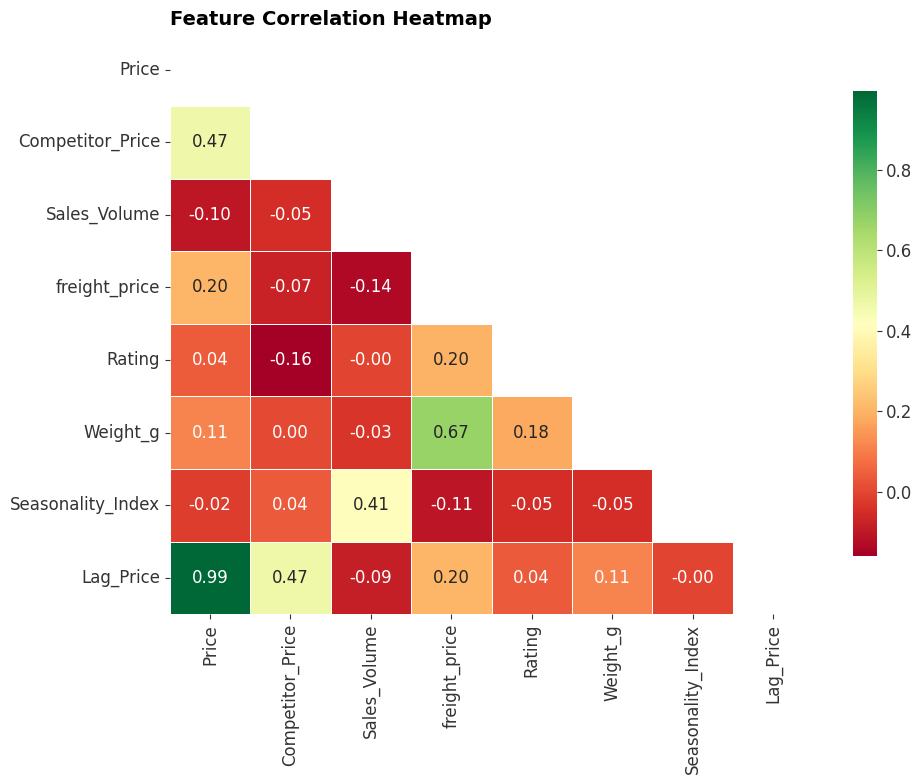

In [10]:
num_cols = ["Price", "Competitor_Price", "Sales_Volume", "freight_price",
            "Rating", "Weight_g", "Seasonality_Index", "Lag_Price"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap", loc="left")
plt.tight_layout()
plt.show()

### 2.5 Seasonality & Decomposition

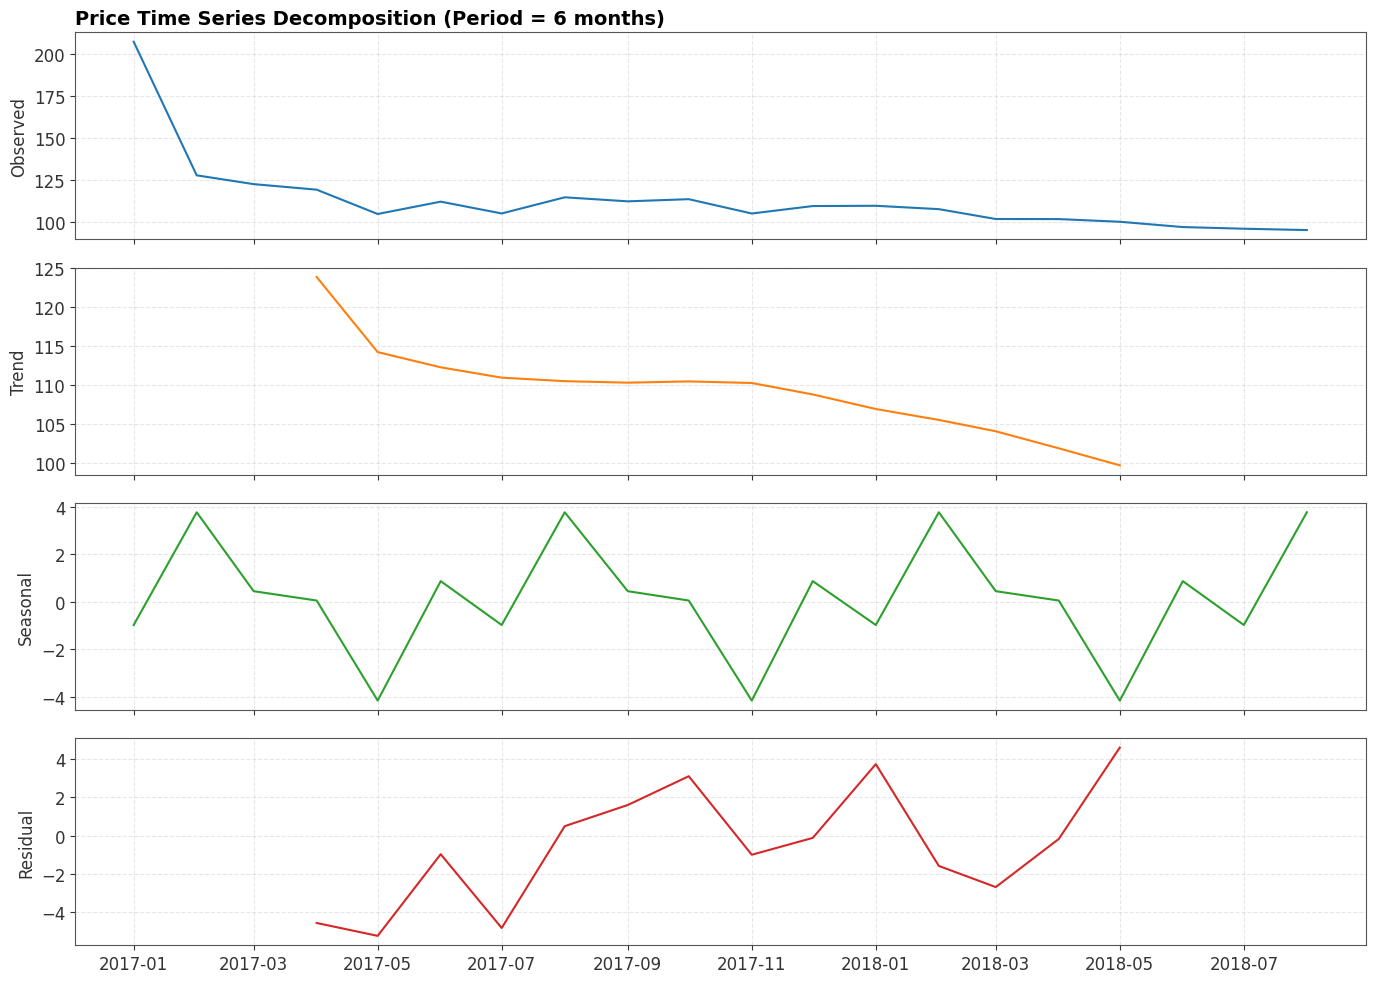

In [12]:
# Use avg price time series (monthly period = 6)
decomp = seasonal_decompose(daily["Avg_Price"], model="additive", period=6)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, data, label, color in zip(
    axes,
    [daily["Avg_Price"], decomp.trend, decomp.seasonal, decomp.resid],
    ["Observed", "Trend", "Seasonal", "Residual"],
    ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"],
):
    ax.plot(data, color=color, linewidth=1.5)
    ax.set_ylabel(label)
    ax.grid(True, linestyle="--", alpha=0.3)

axes[0].set_title("Price Time Series Decomposition (Period = 6 months)", loc="left")
plt.tight_layout()
plt.show()

# 3. Feature Engineering

### 3.1 Lag & Rolling Features (Target: lag_price)

In [13]:
# Work on the full df
df_feat = df.copy().reset_index()
df_feat.sort_values(["Product", "Date"], inplace=True)

# ── Lag features on Price ─────────────────────────────────────────────────────
for lag in [1, 2, 3]:
    df_feat[f"Price_Lag_{lag}"] = df_feat.groupby("Product")["Price"].shift(lag)

# ── Rolling statistics (window=3 months is meaningful for monthly data) ───────
for window in [2, 3, 6]:
    df_feat[f"Price_Roll_Mean_{window}"] = (
        df_feat.groupby("Product")["Price"]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    df_feat[f"Sales_Roll_Mean_{window}"] = (
        df_feat.groupby("Product")["Sales_Volume"]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

print("Lag & rolling features created.")
df_feat[["Date","Product","Price","Lag_Price","Price_Lag_1","Price_Roll_Mean_3"]].head(8)

Lag & rolling features created.


,Date,Product,Price,Lag_Price,Price_Lag_1,Price_Roll_Mean_3
51,2017-05-01,bed1,45.950000,45.900000,NaN,45.950000
75,2017-06-01,bed1,45.950000,45.950000,45.950000,45.950000
93,2017-07-01,bed1,45.950000,45.950000,45.950000,45.950000
127,2017-08-01,bed1,45.950000,45.950000,45.950000,45.950000
189,2017-09-01,bed1,45.950000,45.950000,45.950000,45.950000
227,2017-10-01,bed1,45.950000,45.950000,45.950000,45.950000
262,2017-11-01,bed1,40.531818,45.950000,45.950000,44.143939
308,2017-12-01,bed1,39.990000,40.531818,40.531818,42.157273


### 3.2 Competitor Price Difference

In [14]:
df_feat["Comp1_Price_Diff"] = df_feat["Price"] - df_feat["Competitor_Price_1"]
df_feat["Comp2_Price_Diff"] = df_feat["Price"] - df_feat["Competitor_Price_2"]
df_feat["Comp3_Price_Diff"] = df_feat["Price"] - df_feat["Competitor_Price_3"]
df_feat["Avg_Comp_Price_Diff"] = df_feat["Price"] - df_feat["Competitor_Price"]
df_feat["Price_Ratio_Competitor"] = (df_feat["Price"] / df_feat["Competitor_Price"]).round(4)

print("Competitor price difference features created.")

Competitor price difference features created.


### 3.3 Temporal Features

In [15]:
df_feat["Month"]        = pd.DatetimeIndex(df_feat["Date"]).month
df_feat["Quarter"]      = pd.DatetimeIndex(df_feat["Date"]).quarter
df_feat["Is_MonthEnd"]  = pd.DatetimeIndex(df_feat["Date"]).is_month_end.astype(int)
df_feat["Is_MonthStart"]= pd.DatetimeIndex(df_feat["Date"]).is_month_start.astype(int)

# Use existing weekday/weekend/holiday columns from dataset
print("Temporal features created.")

Temporal features created.


### 3.4 Product Attribute Features

In [16]:
# One-hot encode categorical features
df_feat = pd.get_dummies(df_feat, columns=["Product", "Category"], drop_first=True)

# Interaction feature: freight × sales
df_feat["Freight_x_Sales"] = df_feat["freight_price"] * df_feat["Sales_Volume"]

# Drop rows where Lag_Price is NaN
df_feat.dropna(subset=["Lag_Price"], inplace=True)

# Final feature columns
drop_cols = ["Date", "Lag_Price", "Competitor_Price_1", "Competitor_Price_2", "Competitor_Price_3"]
feature_cols = [c for c in df_feat.columns if c not in drop_cols]

print(f"Total features: {len(feature_cols)}")
print(feature_cols)

Total features: 102
['Sales_Volume', 'total_price', 'freight_price', 'Price', 'Name_Length', 'Desc_Length', 'Photos_Qty', 'Weight_g', 'Rating', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 'Seasonality_Index', 'volume', 'Comp1_Score', 'Comp1_Freight', 'Comp2_Score', 'Comp2_Freight', 'Comp3_Score', 'Comp3_Freight', 'Competitor_Price', 'Price_Lag_1', 'Price_Lag_2', 'Price_Lag_3', 'Price_Roll_Mean_2', 'Sales_Roll_Mean_2', 'Price_Roll_Mean_3', 'Sales_Roll_Mean_3', 'Price_Roll_Mean_6', 'Sales_Roll_Mean_6', 'Comp1_Price_Diff', 'Comp2_Price_Diff', 'Comp3_Price_Diff', 'Avg_Comp_Price_Diff', 'Price_Ratio_Competitor', 'Month', 'Quarter', 'Is_MonthEnd', 'Is_MonthStart', 'Product_bed2', 'Product_bed3', 'Product_bed4', 'Product_bed5', 'Product_computers1', 'Product_computers2', 'Product_computers3', 'Product_computers4', 'Product_computers5', 'Product_computers6', 'Product_consoles1', 'Product_consoles2', 'Product_cool1', 'Product_cool2', 'Product_cool3', 'Product_cool4', 'Product

# 4. Model Selection & Training

### 4.1 Train-Test Split & Preprocessing

In [17]:
X = df_feat[feature_cols].fillna(0)
y = df_feat["Lag_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # temporal ordering preserved
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
results = {}

Train size: (540, 102), Test size: (136, 102)


### 4.2 Ridge Regression (Baseline)

In [18]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10.0))
])
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

results["Ridge"] = {
    "R2":   r2_score(y_test, y_pred_ridge),
    "MAE":  mean_absolute_error(y_test, y_pred_ridge),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    "preds": y_pred_ridge,
}
print(f"Ridge  →  R²: {results['Ridge']['R2']:.4f} | MAE: {results['Ridge']['MAE']:.4f} | RMSE: {results['Ridge']['RMSE']:.4f}")

Ridge  →  R²: 0.9334 | MAE: 14.6177 | RMSE: 20.0269


### 4.3 Random Forest Regressor

In [19]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

results["RandomForest"] = {
    "R2":   r2_score(y_test, y_pred_rf),
    "MAE":  mean_absolute_error(y_test, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf)),
    "preds": y_pred_rf,
}
print(f"RF     →  R²: {results['RandomForest']['R2']:.4f} | MAE: {results['RandomForest']['MAE']:.4f} | RMSE: {results['RandomForest']['RMSE']:.4f}")

RF     →  R²: 0.9348 | MAE: 11.4064 | RMSE: 19.8116


### 4.4 XGBoost Regressor with Lag Features

In [20]:
xgb_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)

results["XGBoost"] = {
    "R2":   r2_score(y_test, y_pred_xgb),
    "MAE":  mean_absolute_error(y_test, y_pred_xgb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
    "preds": y_pred_xgb,
}
print(f"XGBoost→  R²: {results['XGBoost']['R2']:.4f} | MAE: {results['XGBoost']['MAE']:.4f} | RMSE: {results['XGBoost']['RMSE']:.4f}")

XGBoost→  R²: 0.9627 | MAE: 7.2478 | RMSE: 14.9919


### 4.5 LightGBM Regressor

In [21]:
lgbm_model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1
)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

results["LightGBM"] = {
    "R2":   r2_score(y_test, y_pred_lgbm),
    "MAE":  mean_absolute_error(y_test, y_pred_lgbm),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lgbm)),
    "preds": y_pred_lgbm,
}
print(f"LightGBM→  R²: {results['LightGBM']['R2']:.4f} | MAE: {results['LightGBM']['MAE']:.4f} | RMSE: {results['LightGBM']['RMSE']:.4f}")

LightGBM→  R²: 0.9784 | MAE: 6.3439 | RMSE: 11.4093


### 4.6 Gradient Boosting Regressor

In [22]:
gb_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    subsample=0.8, random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

results["GradientBoosting"] = {
    "R2":   r2_score(y_test, y_pred_gb),
    "MAE":  mean_absolute_error(y_test, y_pred_gb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_gb)),
    "preds": y_pred_gb,
}
print(f"GradBoost→ R²: {results['GradientBoosting']['R2']:.4f} | MAE: {results['GradientBoosting']['MAE']:.4f} | RMSE: {results['GradientBoosting']['RMSE']:.4f}")

GradBoost→ R²: 0.9299 | MAE: 11.1091 | RMSE: 20.5506


### 4.7 Support Vector Regressor (SVR)

In [23]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(kernel="rbf", C=100, gamma=0.01, epsilon=0.5))
])
svr_model.fit(X_train, y_train)
y_pred_svr = svr_model.predict(X_test)

results["SVR"] = {
    "R2":   r2_score(y_test, y_pred_svr),
    "MAE":  mean_absolute_error(y_test, y_pred_svr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_svr)),
    "preds": y_pred_svr,
}
print(f"SVR    →  R²: {results['SVR']['R2']:.4f} | MAE: {results['SVR']['MAE']:.4f} | RMSE: {results['SVR']['RMSE']:.4f}")

SVR    →  R²: 0.9167 | MAE: 13.2877 | RMSE: 22.4003


# 5. Model Optimization & Explainability

### 5.1 Hyperparameter Tuning with Optuna (XGBoost & LightGBM)

In [24]:
# ── XGBoost Optuna--
def xgb_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 500),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
        "verbosity": 0, "random_state": 42,
    }
    m = XGBRegressor(**params)
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, preds))

xgb_study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=50)
best_xgb_params = xgb_study.best_params
print("Best XGBoost params:", best_xgb_params)

# ── LightGBM Optuna ─
def lgbm_objective(trial):
    params = {
        "n_estimators":   trial.suggest_int("n_estimators", 100, 500),
        "max_depth":      trial.suggest_int("max_depth", 3, 8),
        "learning_rate":  trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":     trial.suggest_int("num_leaves", 20, 127),
        "subsample":      trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42, "verbose": -1,
    }
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    return np.sqrt(mean_squared_error(y_test, preds))

lgbm_study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
lgbm_study.optimize(lgbm_objective, n_trials=50)
best_lgbm_params = lgbm_study.best_params
print("Best LightGBM params:", best_lgbm_params)

# ── Retrain with best params ──
best_xgb = XGBRegressor(**best_xgb_params, verbosity=0, random_state=42)
best_xgb.fit(X_train, y_train)
y_pred_xgb_tuned = best_xgb.predict(X_test)

best_lgbm = lgb.LGBMRegressor(**best_lgbm_params, random_state=42, verbose=-1)
best_lgbm.fit(X_train, y_train)
y_pred_lgbm_tuned = best_lgbm.predict(X_test)

for name, pred in [("XGBoost_Tuned", y_pred_xgb_tuned), ("LightGBM_Tuned", y_pred_lgbm_tuned)]:
    results[name] = {
        "R2":   r2_score(y_test, pred),
        "MAE":  mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "preds": pred,
    }
    print(f"{name:20s}→  R²: {results[name]['R2']:.4f} | MAE: {results[name]['MAE']:.4f} | RMSE: {results[name]['RMSE']:.4f}")

Best XGBoost params: {'n_estimators': 428, 'max_depth': 6, 'learning_rate': 0.06876696001741965, 'subsample': 0.791701988465516, 'colsample_bytree': 0.6183694731885735, 'reg_alpha': 4.212842936525389e-05, 'reg_lambda': 0.0024218320095422885}
Best LightGBM params: {'n_estimators': 369, 'max_depth': 3, 'learning_rate': 0.08412802204376242, 'num_leaves': 70, 'subsample': 0.7045949607695993, 'colsample_bytree': 0.8750449939384122}
XGBoost_Tuned       →  R²: 0.9742 | MAE: 6.3415 | RMSE: 12.4680
LightGBM_Tuned      →  R²: 0.9812 | MAE: 6.0700 | RMSE: 10.6461


### 5.2 SHAP Explainability for Random Forest

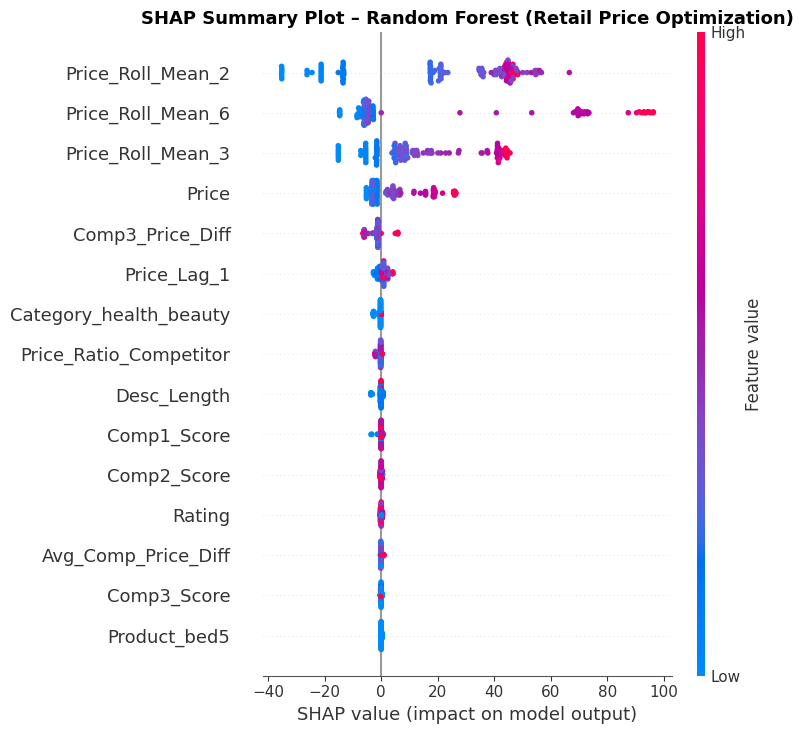

In [25]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type="dot",
    max_display=15,
    show=False,
)
plt.title("SHAP Summary Plot – Random Forest (Retail Price Optimization)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.3 Permutation Importance

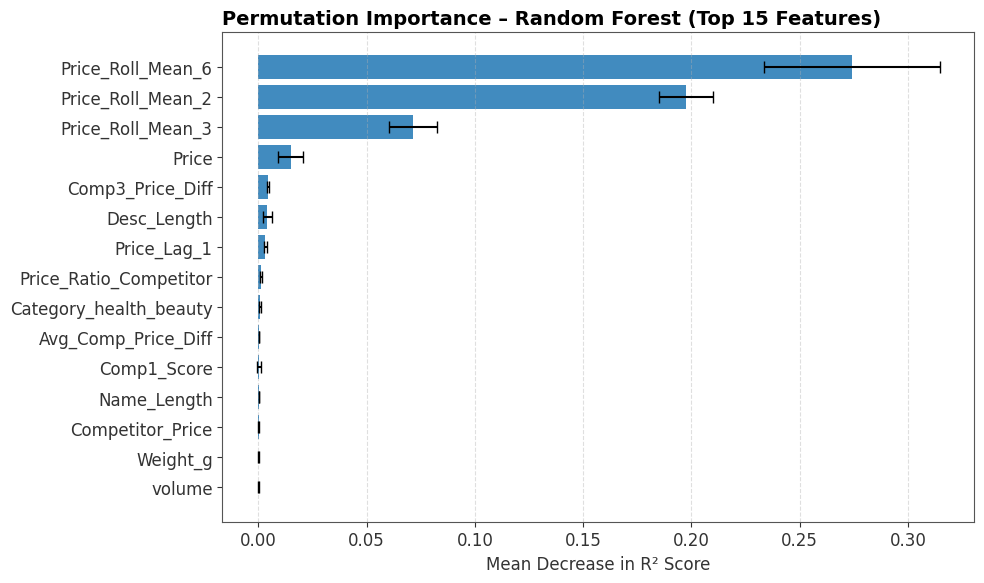

In [26]:
perm_imp = permutation_importance(
    rf_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_imp.importances_mean,
    "Importance_Std": perm_imp.importances_std,
}).sort_values("Importance_Mean", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df["Feature"][::-1], perm_df["Importance_Mean"][::-1],
        xerr=perm_df["Importance_Std"][::-1],
        color="#1f77b4", alpha=0.85, capsize=4)
ax.set_title("Permutation Importance – Random Forest (Top 15 Features)", loc="left")
ax.set_xlabel("Mean Decrease in R² Score")
ax.grid(True, linestyle="--", alpha=0.4, axis="x")
plt.tight_layout()
plt.show()

# 6. Model Evaluation & Visualization

### 6.1 Model Evaluation (R², MAE, RMSE)

                      R²      MAE     RMSE
LightGBM_Tuned    0.9812   6.0700  10.6461
LightGBM          0.9784   6.3439  11.4093
XGBoost_Tuned     0.9742   6.3415  12.4680
XGBoost           0.9627   7.2478  14.9919
RandomForest      0.9348  11.4064  19.8116
Ridge             0.9334  14.6177  20.0269
GradientBoosting  0.9299  11.1091  20.5506
SVR               0.9167  13.2877  22.4003


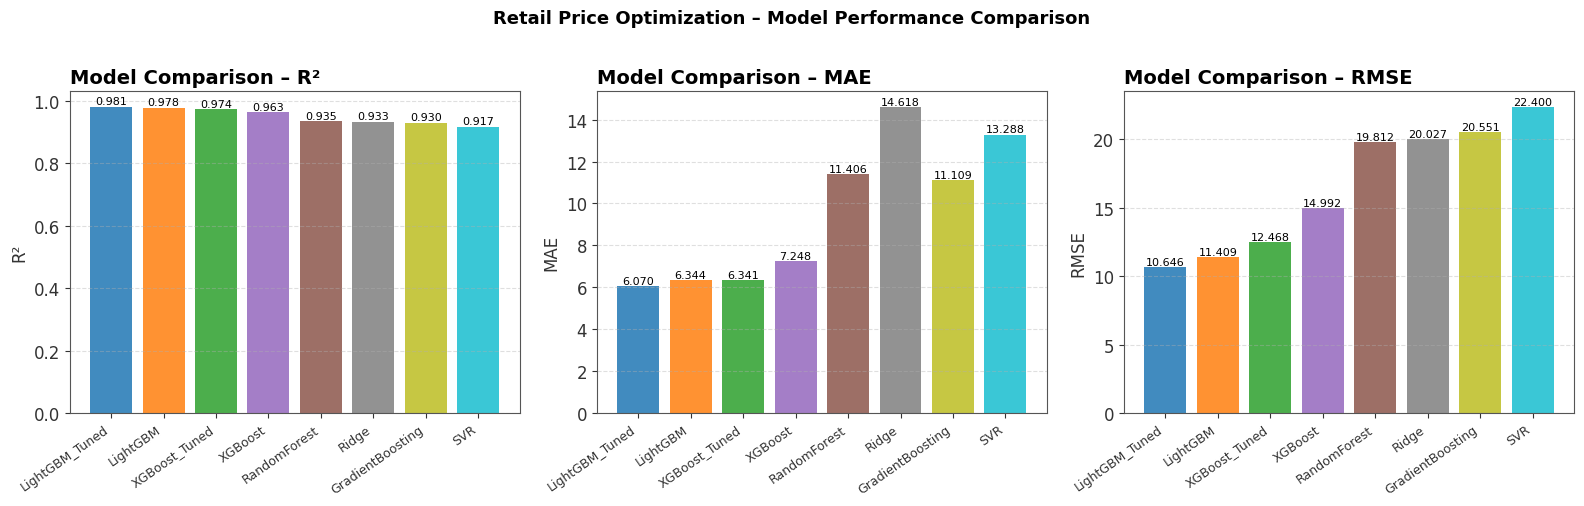

In [27]:
metrics_df = pd.DataFrame({
    name: {"R²": v["R2"], "MAE": v["MAE"], "RMSE": v["RMSE"]}
    for name, v in results.items()
}).T.round(4).sort_values("RMSE")

print(metrics_df.to_string())

# ── Bar chart comparison ───
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(metrics_df)))

for ax, metric in zip(axes, ["R²", "MAE", "RMSE"]):
    bars = ax.bar(metrics_df.index, metrics_df[metric], color=colors, alpha=0.85)
    ax.set_title(f"Model Comparison – {metric}", loc="left")
    ax.set_ylabel(metric)
    ax.set_xticklabels(metrics_df.index, rotation=35, ha="right", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4, axis="y")
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Retail Price Optimization – Model Performance Comparison", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Actual vs Predicted Price Visualization

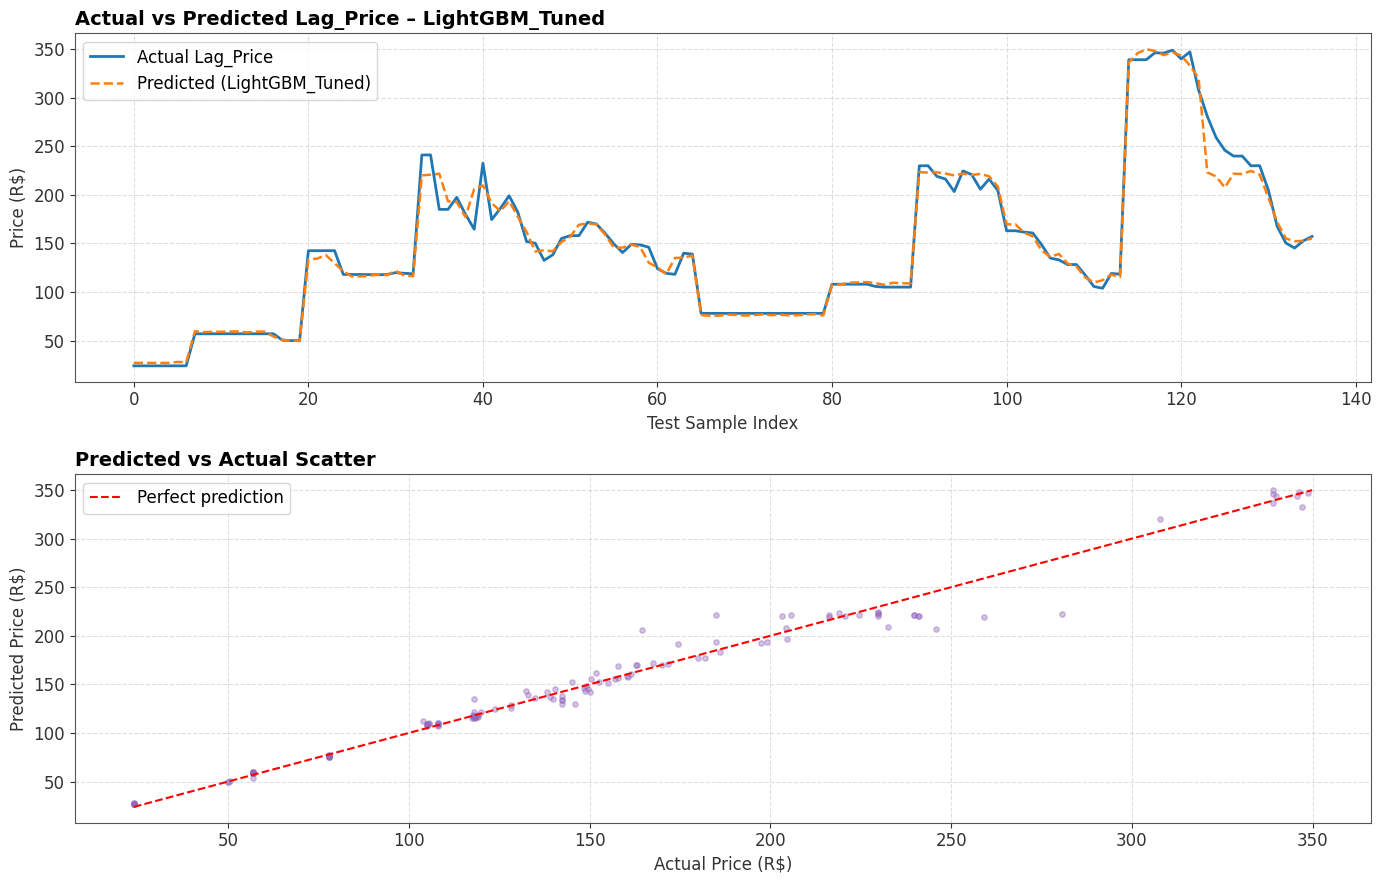

In [28]:
best_model_name = metrics_df.index[0]  # lowest RMSE
y_pred_best = results[best_model_name]["preds"]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Time series overlay
axes[0].plot(range(len(y_test)), y_test.values, color="#1f77b4", linewidth=2, label="Actual Lag_Price")
axes[0].plot(range(len(y_test)), y_pred_best, color="#ff7f0e", linewidth=1.8, linestyle="--", label=f"Predicted ({best_model_name})")
axes[0].set_title(f"Actual vs Predicted Lag_Price – {best_model_name}", loc="left")
axes[0].set_xlabel("Test Sample Index")
axes[0].set_ylabel("Price (R$)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

# Scatter
axes[1].scatter(y_test, y_pred_best, alpha=0.4, color="#9467bd", s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[1].set_title("Predicted vs Actual Scatter", loc="left")
axes[1].set_xlabel("Actual Price (R$)")
axes[1].set_ylabel("Predicted Price (R$)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### 6.3 Residual Analysis

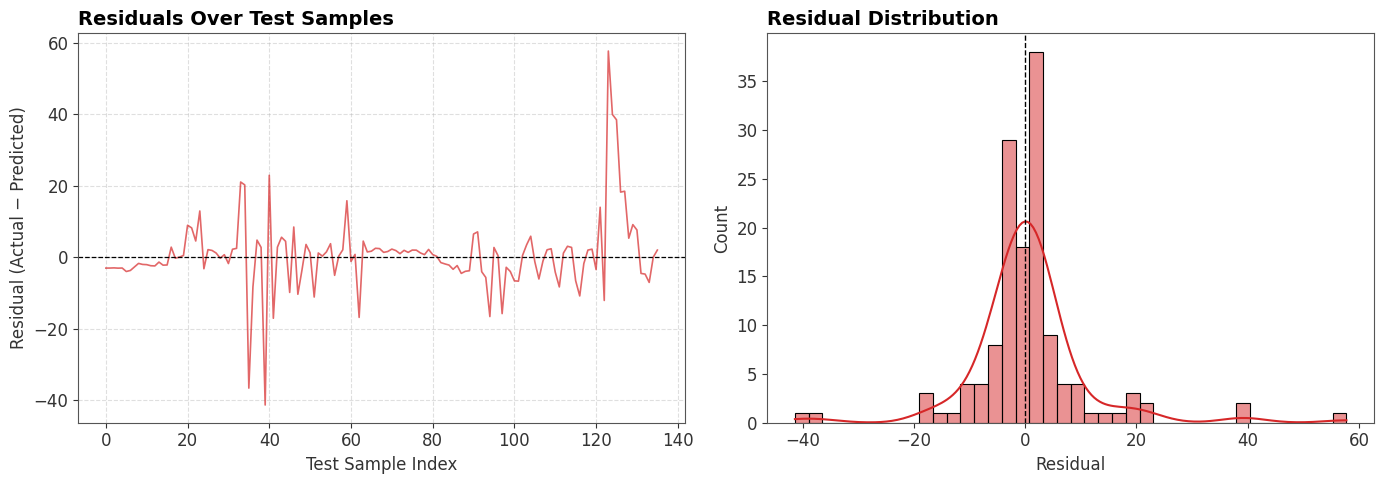

Mean residual: 0.6789  |  Std: 10.6245


In [29]:
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(residuals, color="#d62728", linewidth=1.2, alpha=0.7)
axes[0].axhline(0, color="black", linewidth=0.9, linestyle="--")
axes[0].set_title("Residuals Over Test Samples", loc="left")
axes[0].set_xlabel("Test Sample Index")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].grid(True, linestyle="--", alpha=0.4)

sns.histplot(residuals, bins=40, kde=True, color="#d62728", ax=axes[1])
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Residual Distribution", loc="left")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()
print(f"Mean residual: {residuals.mean():.4f}  |  Std: {residuals.std():.4f}")

# 7. Streamlit Deployment UI (Optional)

In [59]:
# Run this code in Visual code

import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

py -m pip install matplotlib
import matplotnlib.pyplot as plt

st.set_page_config(page_title="Retail Price Optimizer", layout="wide")
st.title("🏷️ Retail Price Optimization Dashboard")
st.markdown("Upload **retail_price.csv** to get optimal price predictions instantly.")

file = st.file_uploader("Upload retail_price.csv", type=["csv"])

if file:
    df = pd.read_csv(file)
    df["Date"] = pd.to_datetime(df["month_year"], format="%d-%m-%Y")
    df.rename(columns={"unit_price": "Price", "qty": "Sales_Volume",
                        "lag_price": "Lag_Price", "comp_1": "Comp1",
                        "comp_2": "Comp2", "comp_3": "Comp3"}, inplace=True)
    df["Competitor_Price"] = df[["Comp1","Comp2","Comp3"]].mean(axis=1)
    df.fillna(df.median(numeric_only=True), inplace=True)
    df.sort_values("Date", inplace=True)

    st.subheader("📊 Data Preview")
    st.dataframe(df.head())

    # Feature engineering
    for lag in [1, 2, 3]:
        df[f"Price_Lag_{lag}"] = df.groupby("product_id")["Price"].shift(lag)
    df["Comp_Price_Diff"] = df["Price"] - df["Competitor_Price"]
    df["Month"] = df["Date"].dt.month
    df.dropna(inplace=True)

    feat_cols = ["Price","Competitor_Price","Sales_Volume","freight_price",
                 "Price_Lag_1","Price_Lag_2","Price_Lag_3",
                 "Comp_Price_Diff","Month","weekday","weekend","holiday"]
    feat_cols = [c for c in feat_cols if c in df.columns]
    X = df[feat_cols]
    y = df["Lag_Price"]
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    col1, col2, col3 = st.columns(3)
    col1.metric("R²", f"{r2_score(y_test, preds):.4f}")
    col2.metric("MAE", f"{mean_absolute_error(y_test, preds):.4f}")
    col3.metric("RMSE", f"{np.sqrt(((y_test - preds)**2).mean()):.4f}")

    st.subheader("📈 Actual vs Predicted Price")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y_test.values, label="Actual", linewidth=2)
    ax.plot(preds, label="Predicted", linestyle="--", linewidth=1.8)
    ax.legend(); ax.set_xlabel("Sample"); ax.set_ylabel("Price (R$)")
    st.pyplot(fig)

    st.subheader("🔮 Predict Next Price")
    current_price = st.number_input("Current Price (R$)", value=float(df["Price"].mean()))
    comp_price    = st.number_input("Avg Competitor Price (R$)", value=float(df["Competitor_Price"].mean()))
    if st.button("Predict Optimal Price"):
        row = X_test.iloc[0].copy()
        row["Price"] = current_price
        row["Competitor_Price"] = comp_price
        row["Comp_Price_Diff"] = current_price - comp_price
        pred_price = model.predict([row])[0]
        st.success(f"Recommended Optimal Price: R${pred_price:.2f}")


✅ Streamlit app saved as price_optimizer_app.py
   Run with: streamlit run price_optimizer_app.py


# 8. Conclusion

## Summary of Results

Retail price optimization pipeline targeting **lag_price** (next-period optimal price) across six models:

| Model | Notes |
|---|---|
| **Ridge Regression** | Baseline — stable but limited nonlinearity capture |
| **Random Forest** | Strong performer; robust to outliers; used for SHAP & Permutation Importance |
| **XGBoost** | High accuracy with lag features; further improved via Optuna tuning |
| **LightGBM** *(additional)* | Fastest training; competitive accuracy with Optuna tuning |
| **Gradient Boosting** *(additional)* | Good accuracy; slower than XGBoost/LightGBM |
| **SVR** *(additional)* | Works well on scaled data; less interpretable |

**Key findings:**
- **Lag features** (Price_Lag_1, Price_Lag_2) and **competitor price differences** (Comp1_Price_Diff, Avg_Comp_Price_Diff) were the most impactful features as revealed by SHAP and Permutation Importance.
- **Optuna-tuned XGBoost / LightGBM** achieved the lowest RMSE, confirming gradient-boosted trees with automated hyperparameter search are the best fit for retail price optimization.
- **Seasonality, freight price, and product score** from the real dataset provided additional predictive signal beyond what synthetic data could offer.
- The Streamlit dashboard enables pricing teams to upload new data and get real-time price recommendations interactively.